# Baseline Technical Analysis — SMA Crossover with ATR Risk

This notebook establishes a **baseline** quantitative workflow for evaluating a technical
strategy. Nothing fancy — the goal is to build a rigorous pipeline we can keep reusing:

1. **Load** every OHLC CSV from `../data/` (filename format `<ASSET>_<TF>_<START>_<END>.csv`).
2. **Describe** a simple, fully-specified strategy (entry, exit, risk plan).
3. **Backtest** it and compute the standard performance metrics (Sharpe, profit factor,
   max drawdown, max consecutive losses, win rate, number of trades, t-statistic on the
   trade distribution, etc.).
4. **Visualize** the results with a dashboard (equity curve, drawdown, PnL distribution,
   rolling win rate).
5. **Optimize** parameters with **Walk-Forward Optimization** (WFO) and inspect the
   stitched out-of-sample performance.
6. **Stress-test** the robustness of the result (Monte-Carlo trade-order shuffling and
   parameter-sensitivity sweeps).

The heavy lifting lives in `../source/` so other notebooks can reuse the same components.


In [1]:
# Make the `source/` package importable from this notebook's location.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from source import (
    load_all,
    resample_ohlc,
    SMACrossoverStrategy,
    StrategyParams,
    Backtester,
    compute_metrics,
    metrics_table,
    plot_backtest_dashboard,
    plot_wfo_dashboard,
    plot_robustness_dashboard,
    walk_forward,
    monte_carlo_trades,
    monte_carlo_summary,
    parameter_sensitivity,
)

pd.set_option("display.float_format", "{:,.4f}".format)
plt.rcParams["figure.dpi"] = 110


## 1. Load the data

`load_all` scans `../data/`, parses filenames of the form
`<ASSET>_<TIMEFRAME>_<STARTYYYYMMDDHHMM>_<ENDYYYYMMDDHHMM>.csv` and returns a dictionary
keyed by `(asset, timeframe)`. Files whose names don't match the scheme are ignored.


In [2]:
datasets = load_all(REPO_ROOT / "data")
print(f"Loaded {len(datasets)} dataset(s):")
for (asset, tf), (meta, df) in datasets.items():
    print(f"  {asset} {tf}  rows={len(df):>8,}  {meta.start} -> {meta.end}")


Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Incorrect Sep...
Loaded 3 dataset(s):
  EURCAD M1  rows=3,719,603  2016-04-11 00:00:00 -> 2026-04-21 23:58:00
  EURUSD M1  rows=3,717,726  2016-04-11 00:00:00 -> 2026-04-21 23:58:00
  GBPCHF M1  rows=3,715,005  2016-04-11 00:00:00 -> 2026-04-21 23:58:00


Pick a dataset to work with. We resample minute data to 1-hour bars to keep the
baseline backtest and WFO runtime reasonable — the pipeline is identical on the original
timeframe, only slower.


In [ ]:
if datasets:
    dfs = []

    for (asset, tf), (meta, df_raw) in datasets.items():
        print(f"Processing {meta.asset} {meta.timeframe} ({len(df_raw):,} rows)")

        df_tmp = (
            resample_ohlc(df_raw, "1h")
            if meta.timeframe.upper() in {"M1", "M5", "M15", "M30"}
            else df_raw
        )

        # Rename columns: <col>_<asset>
        df_tmp = df_tmp.add_suffix(f"_{meta.asset}")

        dfs.append(df_tmp)

    # Combine all dataframes on the index
    df = pd.concat(dfs, axis=1).sort_index()

    print(f"Final shape: {df.shape}")
    print(f"From {df.index[0]} to {df.index[-1]}")

else:
    print("No CSV files found in ../data/. Generating synthetic data.")

    rng = np.random.default_rng(0)
    idx = pd.date_range("2018-01-01", periods=40000, freq="1h")
    returns = rng.normal(0, 0.0008, size=len(idx))
    close = 1.10 * np.exp(np.cumsum(returns))
    high = close * (1 + rng.uniform(0, 0.0010, size=len(idx)))
    low = close * (1 - rng.uniform(0, 0.0010, size=len(idx)))
    open_ = np.r_[close[0], close[:-1]]

    df = pd.DataFrame(
        {"open": open_, "high": high, "low": low, "close": close},
        index=idx
    )

df.head()

Using EURCAD M1  (3,719,603 rows)
After resampling: 62,351 rows from 2016-04-11 00:00:00 to 2026-04-21 23:00:00


,open,high,low,close,spread,volume,tick_vol
datetime,,,,,,,
2016-04-11 00:00:00,1.4809,1.4823,1.4799,1.4816,6348,335050000,800
2016-04-11 01:00:00,1.4816,1.4817,1.4803,1.4805,2824,3648449000,3846
2016-04-11 02:00:00,1.4805,1.4813,1.4797,1.4801,2151,1804350000,2852
2016-04-11 03:00:00,1.4802,1.4824,1.4797,1.4815,2062,2416250000,4341
2016-04-11 04:00:00,1.4815,1.4859,1.4810,1.4834,2000,2472800000,4943


## 2. Strategy definition — SMA crossover with ATR-based risk

**Entry**
- Long when the fast SMA crosses above the slow SMA (bar close).
- Short when the fast SMA crosses below the slow SMA.

**Exit**
- Hard stop loss: `entry - direction * sl_atr_mult * ATR`.
- Take profit: `entry + direction * tp_atr_mult * ATR`.
- Reverse on the opposite crossover.

**Risk plan**
- One unit per trade, PnL measured in price points.
- Intrabar priority: stop loss before take profit (pessimistic assumption).
- No pyramiding, always flat between signals.
- Optional slippage can be passed to the backtester if we want to stress the edge.

This is intentionally plain — the purpose is a **baseline**, not a production system.


In [4]:
baseline_params = StrategyParams(
    fast=20,
    slow=50,
    atr_period=14,
    sl_atr_mult=2.0,
    tp_atr_mult=3.0,
)
strategy = SMACrossoverStrategy(baseline_params)
backtester = Backtester(strategy, slippage_points=0.0)
result = backtester.run(df)

print(f"Trades: {len(result.trades):,}")
result.trades.head()


Trades: 1,414


,entry_time,exit_time,direction,entry,exit,reason,pnl_points,bars_held
0,2016-04-15 17:00:00,2016-04-15 22:00:00,1,1.4542,1.4480,SL,-0.0062,5
1,2016-04-19 05:00:00,2016-04-20 16:00:00,-1,1.4458,1.4366,TP,0.0092,35
2,2016-04-22 05:00:00,2016-04-22 15:00:00,1,1.4355,1.4303,SL,-0.0052,10
3,2016-04-22 21:00:00,2016-04-26 08:00:00,-1,1.4241,1.4283,SIGNAL,-0.0042,35
4,2016-04-26 08:00:00,2016-04-26 10:00:00,1,1.4283,1.4252,SL,-0.0031,2


### 2.1 Performance metrics

- **num_trades** — sample size; drives statistical power.
- **win_rate / profit_factor / expectancy** — basic edge descriptors.
- **max_drawdown** — largest peak-to-trough equity decline (points).
- **max_consec_losses** — worst losing streak, useful for sizing.
- **sharpe_daily** — Sharpe of daily equity changes, annualized (×√252).
- **sharpe_per_trade** — trade-level Sharpe ≈ mean/std × √n, scale-free alternative.
- **t_stat / p_value** — one-sample t-test against zero expectancy; `p_value` is a
  normal-approximation two-sided p-value, so it's a rough proxy of statistical relevance.


In [5]:
metrics = compute_metrics(result)
metrics_table(metrics)


,value
metric,
num_trades,"1,414.0000"
total_pnl,-0.3404
win_rate,0.3784
profit_factor,0.8885
expectancy,-0.0002
avg_win,0.0051
avg_loss,-0.0035
max_drawdown,-0.3498
max_consec_losses,12.0000


### 2.2 Baseline dashboard


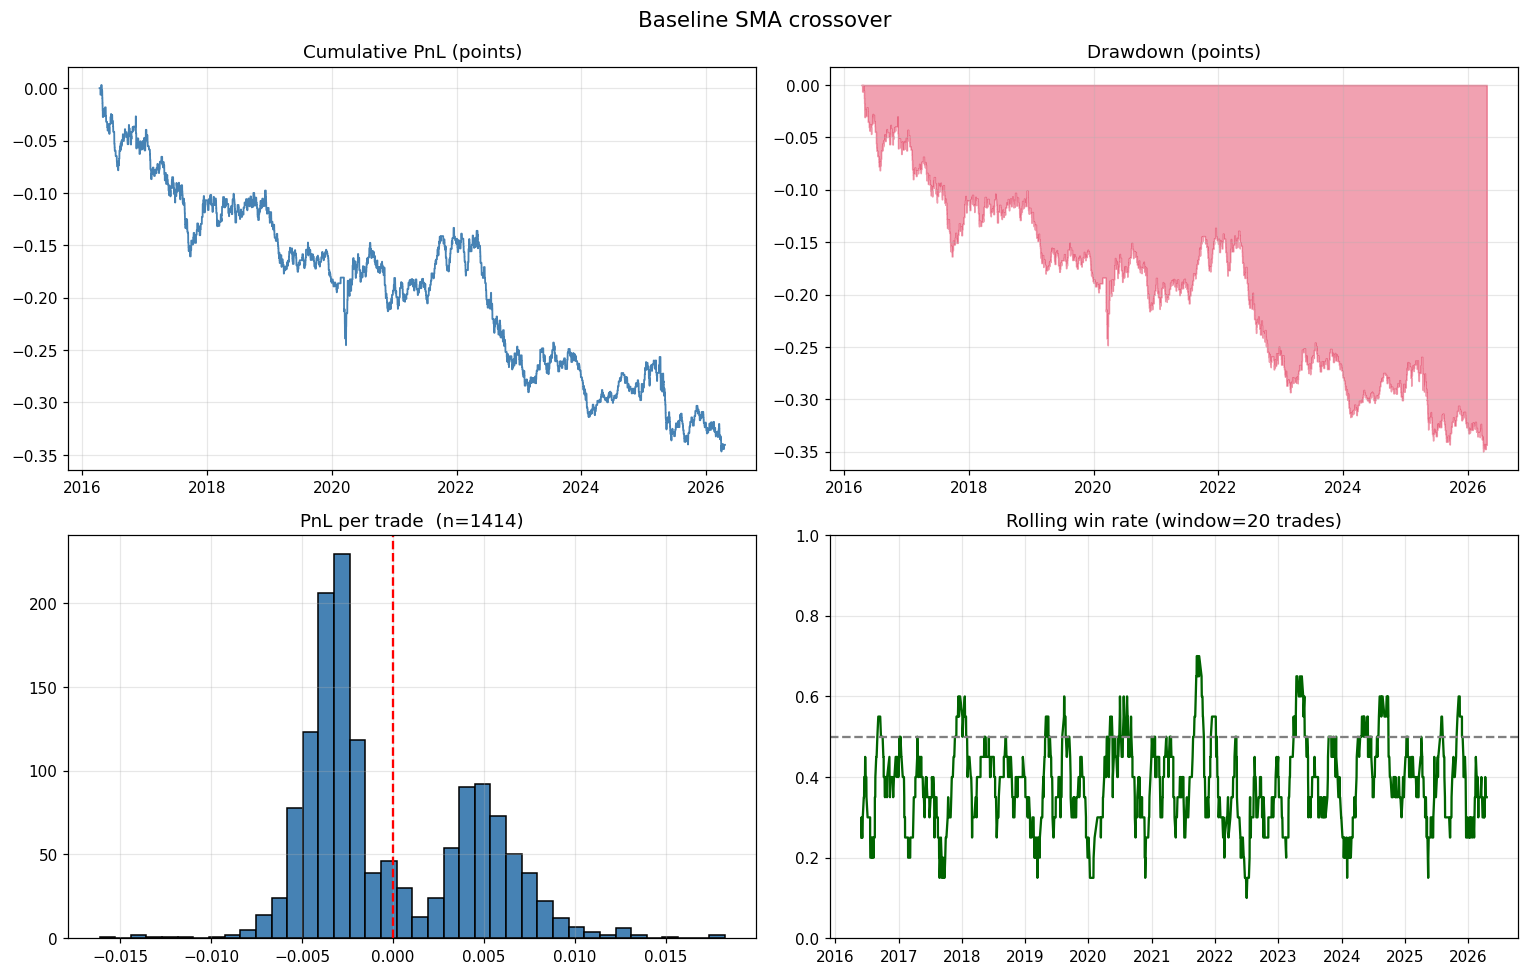

In [6]:
fig = plot_backtest_dashboard(result, title="Baseline SMA crossover")
plt.show()


## 3. Walk-Forward Optimization

We split the series into `n_splits` equal folds. Inside each fold:

- the first `1 - oos_ratio` fraction is **in-sample** (IS): we grid-search the best
  parameters by maximising the daily Sharpe;
- the remaining fraction is **out-of-sample** (OOS): we run the chosen parameters on
  unseen data.

The OOS equity curves are stitched together end-to-end, giving a more honest estimate
of what the strategy would have produced had we re-optimized periodically.


In [7]:
param_grid = {
    "fast":        [10, 20, 30],
    "slow":        [40, 60, 100],
    "sl_atr_mult": [1.5, 2.0, 3.0],
    "tp_atr_mult": [2.0, 3.0, 4.0],
}

wfo = walk_forward(
    df,
    param_grid=param_grid,
    n_splits=5,
    oos_ratio=0.25,
)
wfo.windows


,fold,is_start,is_end,oos_start,oos_end,is_score,oos_pnl,oos_sharpe,oos_profit_factor,oos_win_rate,oos_trades,param_fast,param_slow,param_sl_atr_mult,param_tp_atr_mult
0,0,2016-04-11 00:00:00,2017-10-10 10:00:00,2017-10-10 11:00:00,2018-04-12 10:00:00,0.5769,-0.0221,-0.6389,0.8091,0.2778,36,30,100,2.0000,4.0000
1,1,2018-04-12 11:00:00,2019-10-14 19:00:00,2019-10-14 20:00:00,2020-04-15 22:00:00,0.4811,-0.0072,-0.1646,0.9623,0.4206,107,10,40,1.5000,2.0000
2,2,2020-04-15 23:00:00,2021-10-15 17:00:00,2021-10-15 18:00:00,2022-04-15 18:00:00,1.4055,-0.0037,-0.1387,0.9667,0.4746,59,30,60,2.0000,2.0000
3,3,2022-04-15 19:00:00,2023-10-16 21:00:00,2023-10-16 22:00:00,2024-04-17 23:00:00,0.9226,-0.0301,-1.8901,0.5416,0.2778,36,30,100,2.0000,3.0000
4,4,2024-04-18 00:00:00,2025-10-17 21:00:00,2025-10-17 22:00:00,2026-04-21 23:00:00,1.0831,-0.0804,-2.7447,0.5866,0.3868,106,10,40,3.0000,2.0000


### 3.1 WFO dashboard

We overlay the stitched OOS equity on the baseline single-run equity so it's easy to
see whether re-optimization is actually helping.


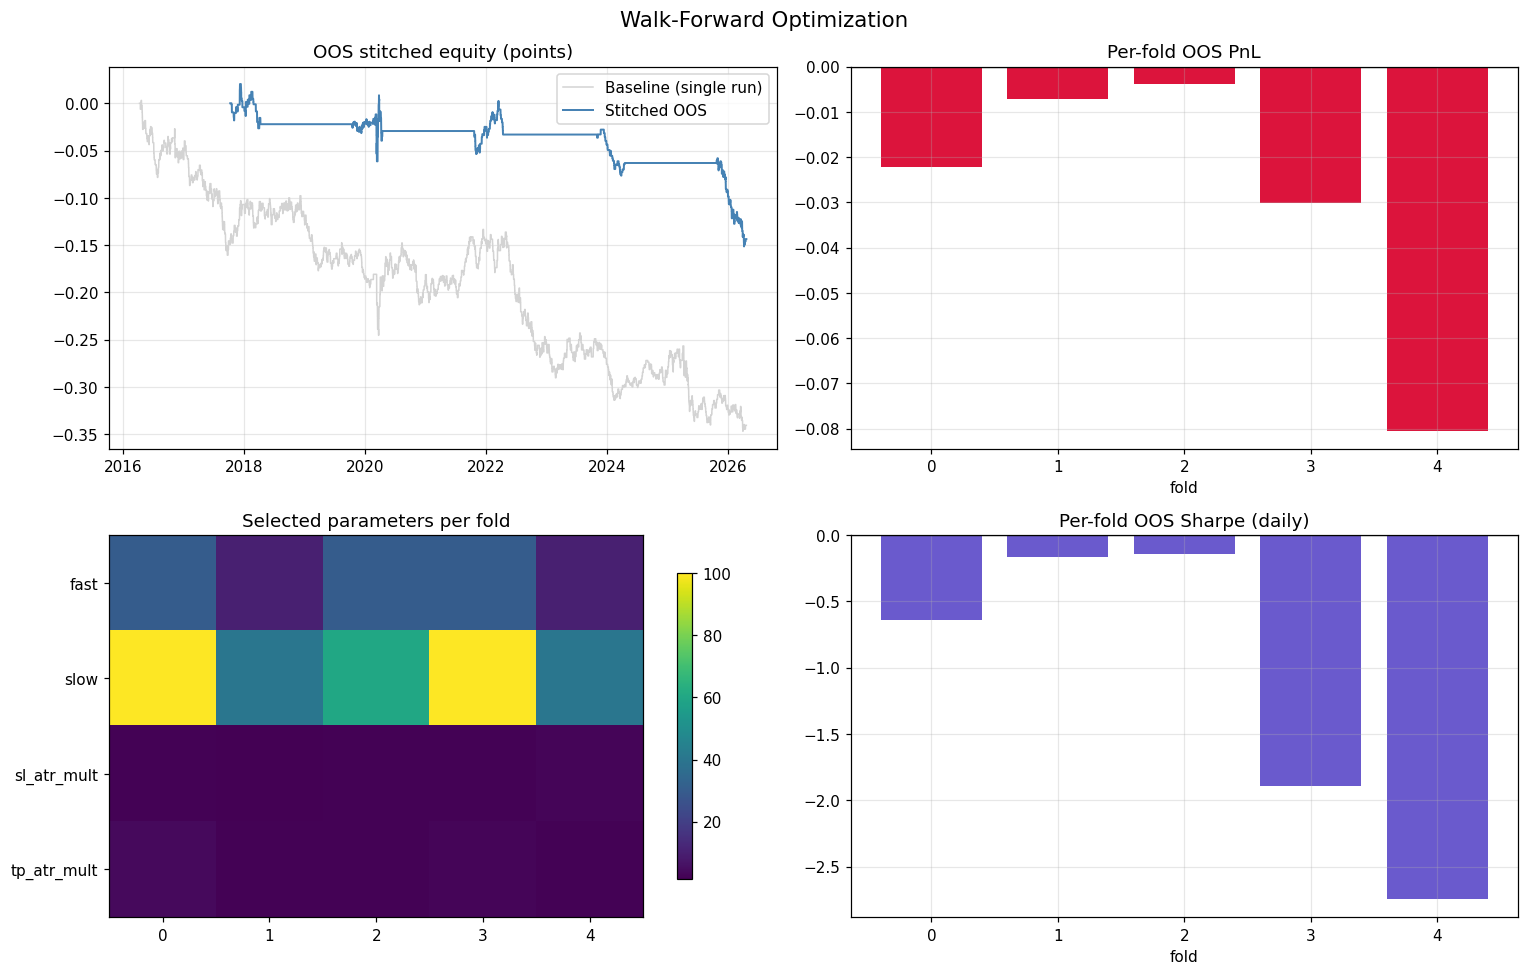

In [8]:
fig = plot_wfo_dashboard(wfo, full_equity=result.equity)
plt.show()


In [9]:
# Aggregate WFO OOS metrics for a one-line summary.
if not wfo.oos_trades.empty:
    class _FakeRes:
        pass
    oos_view = _FakeRes()
    oos_view.trades = wfo.oos_trades
    oos_view.equity = wfo.oos_equity
    oos_metrics = compute_metrics(oos_view)
    print("Aggregated out-of-sample metrics:")
    display(metrics_table(oos_metrics))
else:
    print("WFO produced no OOS trades.")


Aggregated out-of-sample metrics:


,value
metric,
num_trades,344.0000
total_pnl,-0.1436
win_rate,0.3895
profit_factor,0.7888
expectancy,-0.0004
avg_win,0.0040
avg_loss,-0.0032
max_drawdown,-0.1717
max_consec_losses,9.0000


### 3.2 Optimized Backtest

In [10]:
baseline_params = StrategyParams(
    fast=30,
    slow=100,
    atr_period=14,
    sl_atr_mult=3.0,
    tp_atr_mult=4.0,
)
strategy = SMACrossoverStrategy(baseline_params)
backtester = Backtester(strategy, slippage_points=0.0)
result = backtester.run(df)

print(f"Trades: {len(result.trades):,}")
result.trades.head()

Trades: 792


,entry_time,exit_time,direction,entry,exit,reason,pnl_points,bars_held
0,2016-04-18 09:00:00,2016-04-18 13:00:00,1,1.4655,1.4541,SL,-0.0114,4
1,2016-04-19 16:00:00,2016-04-20 18:00:00,-1,1.4410,1.4302,TP,0.0108,26
2,2016-04-29 20:00:00,2016-05-03 13:00:00,1,1.4399,1.4530,TP,0.0131,41
3,2016-05-11 13:00:00,2016-05-11 17:00:00,-1,1.4670,1.4739,SL,-0.0069,4
4,2016-05-18 15:00:00,2016-05-18 18:00:00,1,1.4625,1.4567,SL,-0.0057,3


In [11]:
metrics = compute_metrics(result)
metrics_table(metrics)

,value
metric,
num_trades,792.0000
total_pnl,-0.1000
win_rate,0.4116
profit_factor,0.9562
expectancy,-0.0001
avg_win,0.0067
avg_loss,-0.0049
max_drawdown,-0.3234
max_consec_losses,15.0000


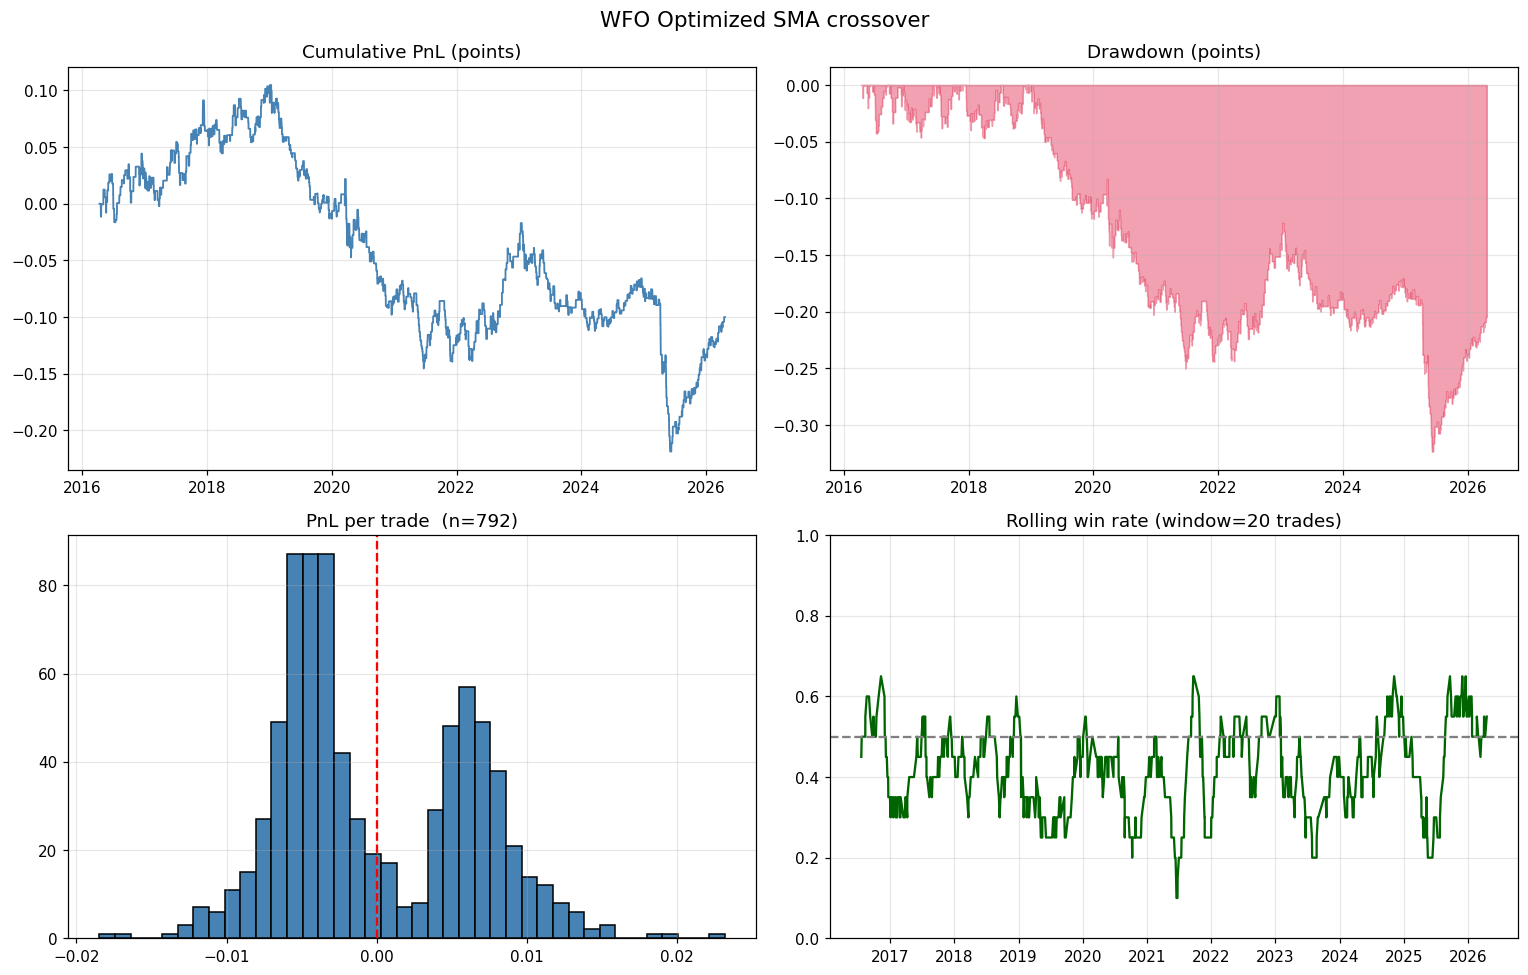

In [12]:
fig = plot_backtest_dashboard(result, title="WFO Optimized SMA crossover")
plt.show()

## 4. Robustness

Two complementary tests:

1. **Monte-Carlo trade-order shuffling.** Keeps the trade distribution fixed but
   randomises the order. This reveals how much of the equity-curve shape is luck vs
   edge, and gives a confidence band for final PnL and max drawdown.
2. **Parameter sensitivity.** One-at-a-time sweeps around the baseline params. A robust
   edge should degrade gradually, not fall off a cliff when a parameter moves by one
   notch.


In [13]:
mc_df = monte_carlo_trades(result.trades, n_runs=1000, seed=42)
summary = monte_carlo_summary(mc_df)
pd.Series(summary).to_frame("value")


,value
mean_final_pnl,-0.1000
median_final_pnl,-0.1000
p05_final_pnl,-0.1000
p95_final_pnl,-0.1000
mean_max_drawdown,-0.2434
p95_max_drawdown,-0.3419
prob_profitable,0.0000


In [14]:
sensitivity = parameter_sensitivity(
    df,
    base_params=baseline_params,
    variations={
        "fast":        [10, 15, 20, 25, 30],
        "slow":        [30, 50, 80, 120],
        "sl_atr_mult": [1.0, 1.5, 2.0, 2.5, 3.0],
        "tp_atr_mult": [1.5, 2.0, 3.0, 4.0, 5.0],
    },
)
sensitivity.head()


,param,value,num_trades,total_pnl,win_rate,avg_win,avg_loss,profit_factor,expectancy,max_drawdown,max_consec_losses,sharpe_daily,sharpe_per_trade,t_stat,p_value
0,fast,10.0000,1134,0.0071,0.3695,0.0071,-0.0042,1.0024,0.0000,-0.1639,11,0.0085,0.0331,0.0331,0.9736
1,fast,15.0000,958,0.0956,0.3987,0.0073,-0.0047,1.0353,0.0001,-0.1946,11,0.1198,0.4602,0.4602,0.6454
2,fast,20.0000,886,-0.0052,0.3916,0.0073,-0.0047,0.9980,-0.0000,-0.2194,16,-0.0070,-0.0267,-0.0267,0.9787
3,fast,25.0000,843,-0.0379,0.4009,0.0072,-0.0049,0.9846,-0.0000,-0.2904,13,-0.0510,-0.1967,-0.1967,0.8441
4,fast,30.0000,792,-0.1000,0.4116,0.0067,-0.0049,0.9562,-0.0001,-0.3234,15,-0.1459,-0.5561,-0.5561,0.5781


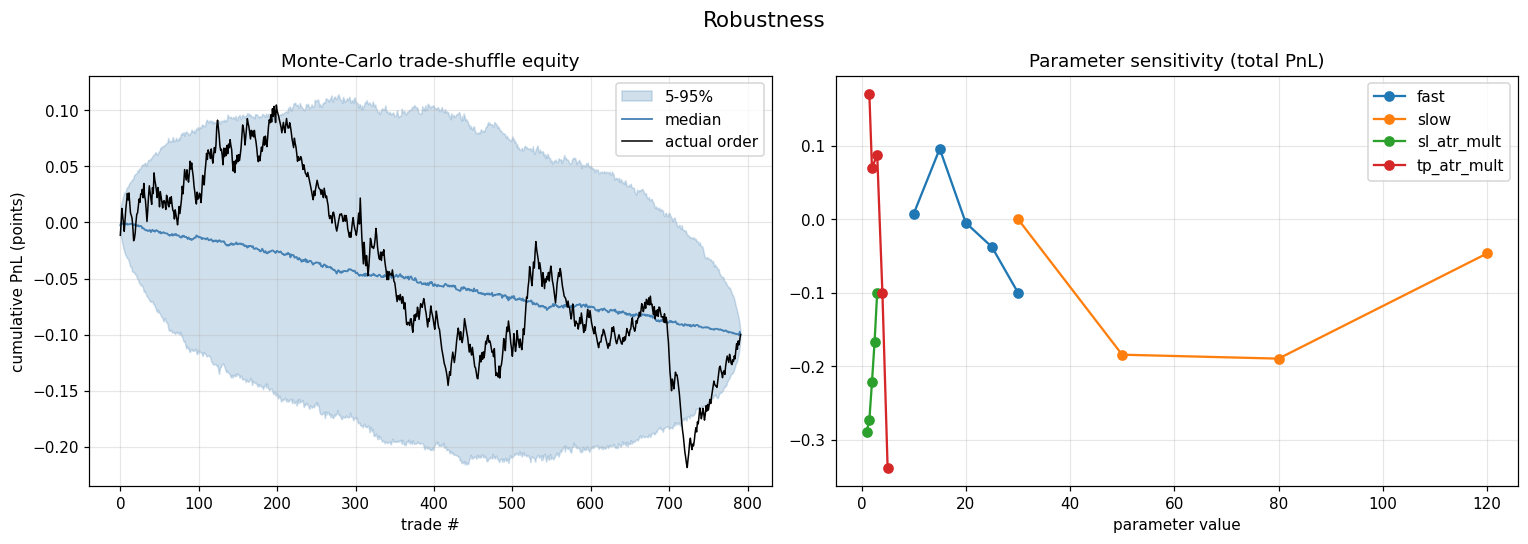

In [15]:
actual_equity = result.trades["pnl_points"].cumsum().values if not result.trades.empty else None
fig = plot_robustness_dashboard(mc_df, baseline_equity=actual_equity, sensitivity=sensitivity)
plt.show()


## 5. Takeaways & next steps

**What this baseline gives us**
- A reproducible load ➜ backtest ➜ metrics ➜ dashboards ➜ WFO ➜ robustness pipeline.
- Reusable classes in `source/` we can plug into other strategies.
- A concrete performance profile to compare future ideas against.

**Known simplifications** (on purpose — these are next iterations, not bugs)
- Execution at bar close, no realistic fill modelling, single unit sizing, no commissions.
- Intra-bar SL-before-TP assumption may under-state TP hits.
- The t-test treats trades as i.i.d., which is only approximately true.
- WFO uses fixed equal folds — anchored/rolling variants with proper retraining cadence
  are a natural follow-up.

**Obvious extensions**
- Volatility-scaled sizing, trailing stops, session/time-of-day filters.
- Classifier/regressor overlays on top of the crossover in the `machine_learning/` folder.
- Portfolio-level backtesting across all datasets discovered by `load_all`.
